In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout,BatchNormalization,Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [34]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/internship-500/energy forecasting /energy_forecasting.csv')
df

,period_end,period,air_temp,dhi,ghi,gti,dni,Reflectivity of Surface,Sun Position,wind_speed_10m
0,2020-01-01T01:00:00+03:00,PT60M,17,0,0,0,0.0,0.33,-89.0,1.0
1,2020-01-01T02:00:00+03:00,PT60M,16,0,0,0,0.0,0.33,-94.0,1.7
2,2020-01-01T03:00:00+03:00,PT60M,15,0,0,0,0.0,0.33,-98.0,2.0
3,2020-01-01T04:00:00+03:00,PT60M,15,0,0,0,0.0,0.33,-102.0,2.3
4,2020-01-01T05:00:00+03:00,PT60M,14,0,0,0,0.0,0.33,-107.0,2.7
...,...,...,...,...,...,...,...,...,...,...
43843,2024-12-31T20:00:00+03:00,PT60M,23,0,0,0,NaN,NaN,NaN,NaN
43844,2024-12-31T21:00:00+03:00,PT60M,22,0,0,0,NaN,NaN,NaN,NaN
43845,2024-12-31T22:00:00+03:00,PT60M,21,0,0,0,NaN,NaN,NaN,NaN
43846,2024-12-31T23:00:00+03:00,PT60M,20,0,0,0,NaN,NaN,NaN,NaN


In [35]:
print("Columns:", df.columns)

Columns: Index(['period_end', 'period', 'air_temp', 'dhi', 'ghi', 'gti', 'dni',
       'Reflectivity of Surface ', 'Sun Position', 'wind_speed_10m'],
      dtype='object')


In [5]:
ghi_min = df['ghi'].min()
ghi_max = df['ghi'].max()
ghi_mean = df['ghi'].mean()
ghi_std = df['ghi'].std()

print(f"GHI Range: {ghi_min} to {ghi_max}")
print(f"GHI Mean: {ghi_mean:.2f}")
print(f"GHI Std Dev: {ghi_std:.2f}")

GHI Range: 0 to 1077
GHI Mean: 251.04
GHI Std Dev: 329.65


In [6]:
target_column = 'ghi'
data = df[target_column].ffill().values.reshape(-1, 1)

In [7]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)


In [8]:
look_back = 1095
look_forward = 3650
n_features=1

In [9]:
X, y = [], []
for i in range(len(data_scaled) - look_back - look_forward):
    X.append(data_scaled[i:i + look_back])
    y.append(data_scaled[i + look_back:i + look_back + look_forward])

X = np.array(X)
y = np.array(y)

In [10]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [31]:
model = Sequential()
model.add(Input(shape=(look_back, 1)))

model.add(Conv1D(filters=64, kernel_size=5, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))
model.add(LSTM(256))
model.add(Dense(look_forward))
model.compile(optimizer='adam', loss='mse')
model.summary()

NameError: name 'Input' is not defined

In [12]:
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1095, 64)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1095, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 547, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 547, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 547, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 547, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 273, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 273, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 273, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 273, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 375,297 (1.43 MB)

 Trainable params: 374,913 (1.43 MB)

 Non-trainable params: 384 (1.50 KB)

In [13]:
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)


In [14]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
978/978 ━━━━━━━━━━━━━━━━━━━━ 50s 43ms/step - loss: 0.0979 - val_loss: 0.0946
Epoch 2/50
978/978 ━━━━━━━━━━━━━━━━━━━━ 76s 41ms/step - loss: 0.0950 - val_loss: 0.0939
Epoch 3/50
978/978 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - loss: 0.0948 - val_loss: 0.0951
Epoch 4/50
978/978 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - loss: 0.0949 - val_loss: 0.0937
Epoch 5/50
978/978 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - loss: 0.0945 - val_loss: 0.0943
Epoch 6/50
978/978 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - loss: 0.0944 - val_loss: 0.0937
Epoch 7/50
978/978 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - loss: 0.0945 - val_loss: 0.0938
Epoch 8/50
978/978 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - loss: 0.0944 - val_loss: 0.0937
Epoch 9/50
978/978 ━━━━━━━━━━━━━━━━━━━━ 42s 43ms/step - loss: 0.0945 - val_loss: 0.0937
Epoch 10/50
978/978 ━━━━━━━━━━━━━━━━━━━━ 81s 41ms/step - loss: 0.0945 - val_loss: 0.0938


In [15]:
y_pred = model.predict(X_test)

245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step


In [23]:
print(y_pred.shape)
print(y_test.shape)  # This will help debug


(7821, 1)
(7821, 3650, 1)


In [24]:
y_test_last = y_test[:, -1, :]  # shape will be (7821, 1)

In [25]:
y_test_inv = scaler.inverse_transform(y_test_last)
y_pred_inv = scaler.inverse_transform(y_pred)


In [26]:
# Then compute metrics
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

In [27]:
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R-squared (R² Score): {r2:.3f}")

RMSE: 334.24
MAE: 293.64
R-squared (R² Score): -0.000


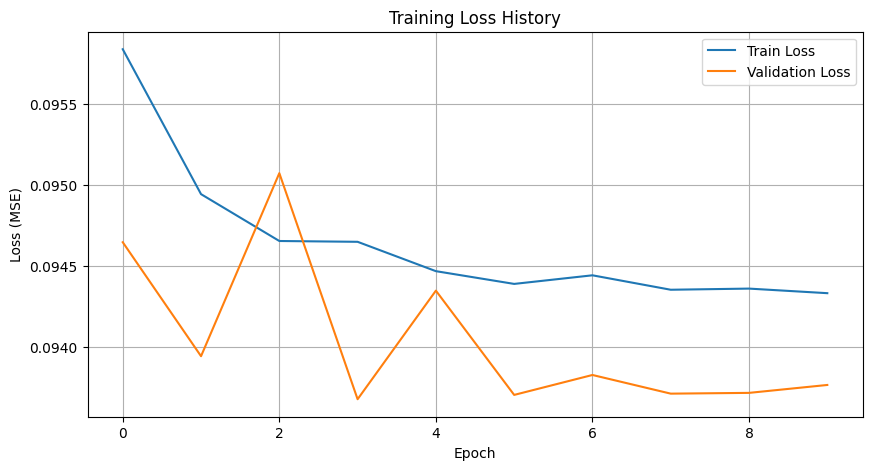

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

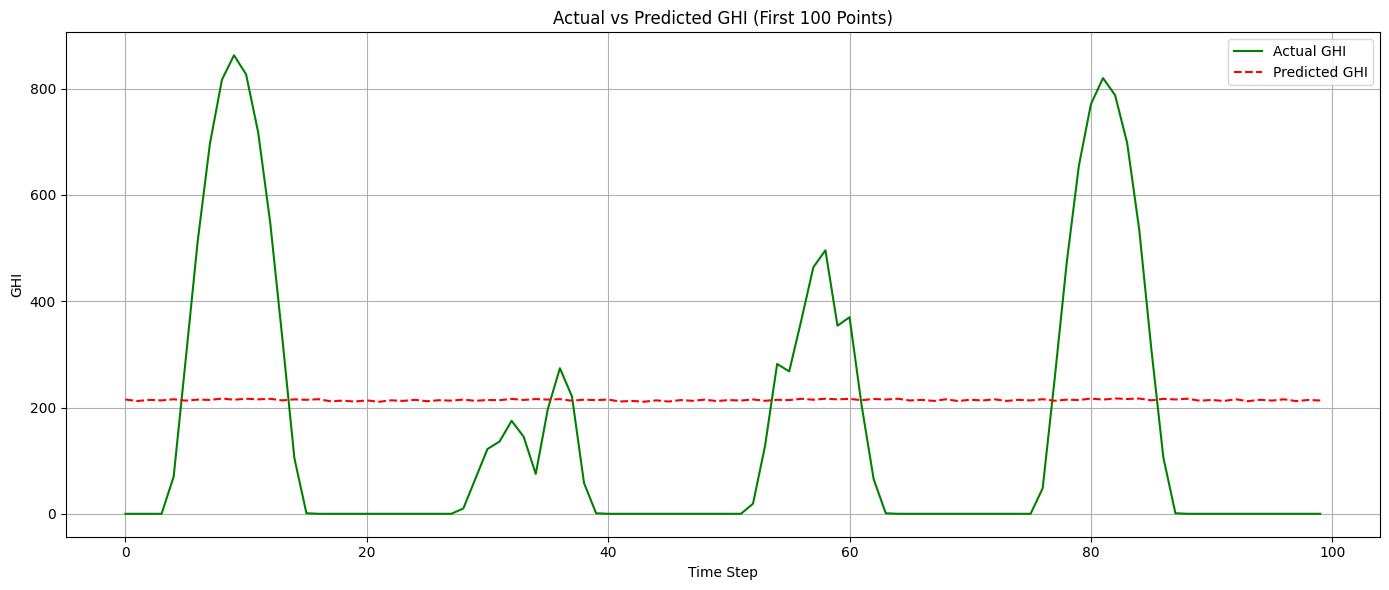

In [29]:
plt.figure(figsize=(14, 6))
plt.plot(y_test_inv[:100], label='Actual GHI', color='green')
plt.plot(y_pred_inv[:100], label='Predicted GHI', color='red', linestyle='--')
plt.title('Actual vs Predicted GHI (First 100 Points)')
plt.xlabel('Time Step')
plt.ylabel('GHI')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<ipython-input-30-72f45e4e626c>:9: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


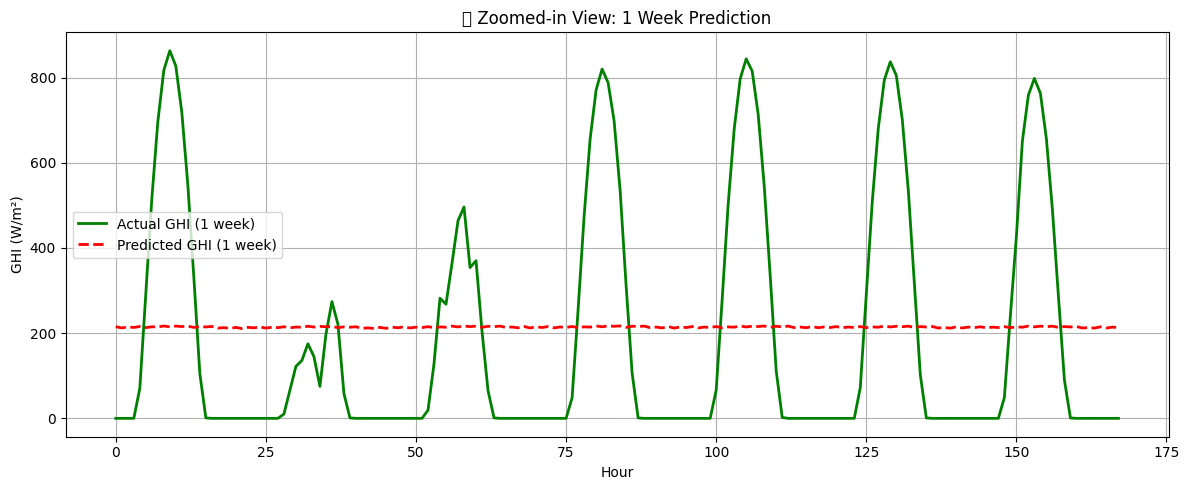

In [30]:
plt.figure(figsize=(12, 5))
plt.plot(y_test_inv[:168], label='Actual GHI (1 week)', color='green', linewidth=2)
plt.plot(y_pred_inv[:168], label='Predicted GHI (1 week)', color='red', linestyle='--', linewidth=2)
plt.title('🔍 Zoomed-in View: 1 Week Prediction')
plt.xlabel('Hour')
plt.ylabel('GHI (W/m²)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()